In [1]:
%matplotlib notebook

In [2]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp

0.09832857142857145


<IPython.core.display.Javascript object>


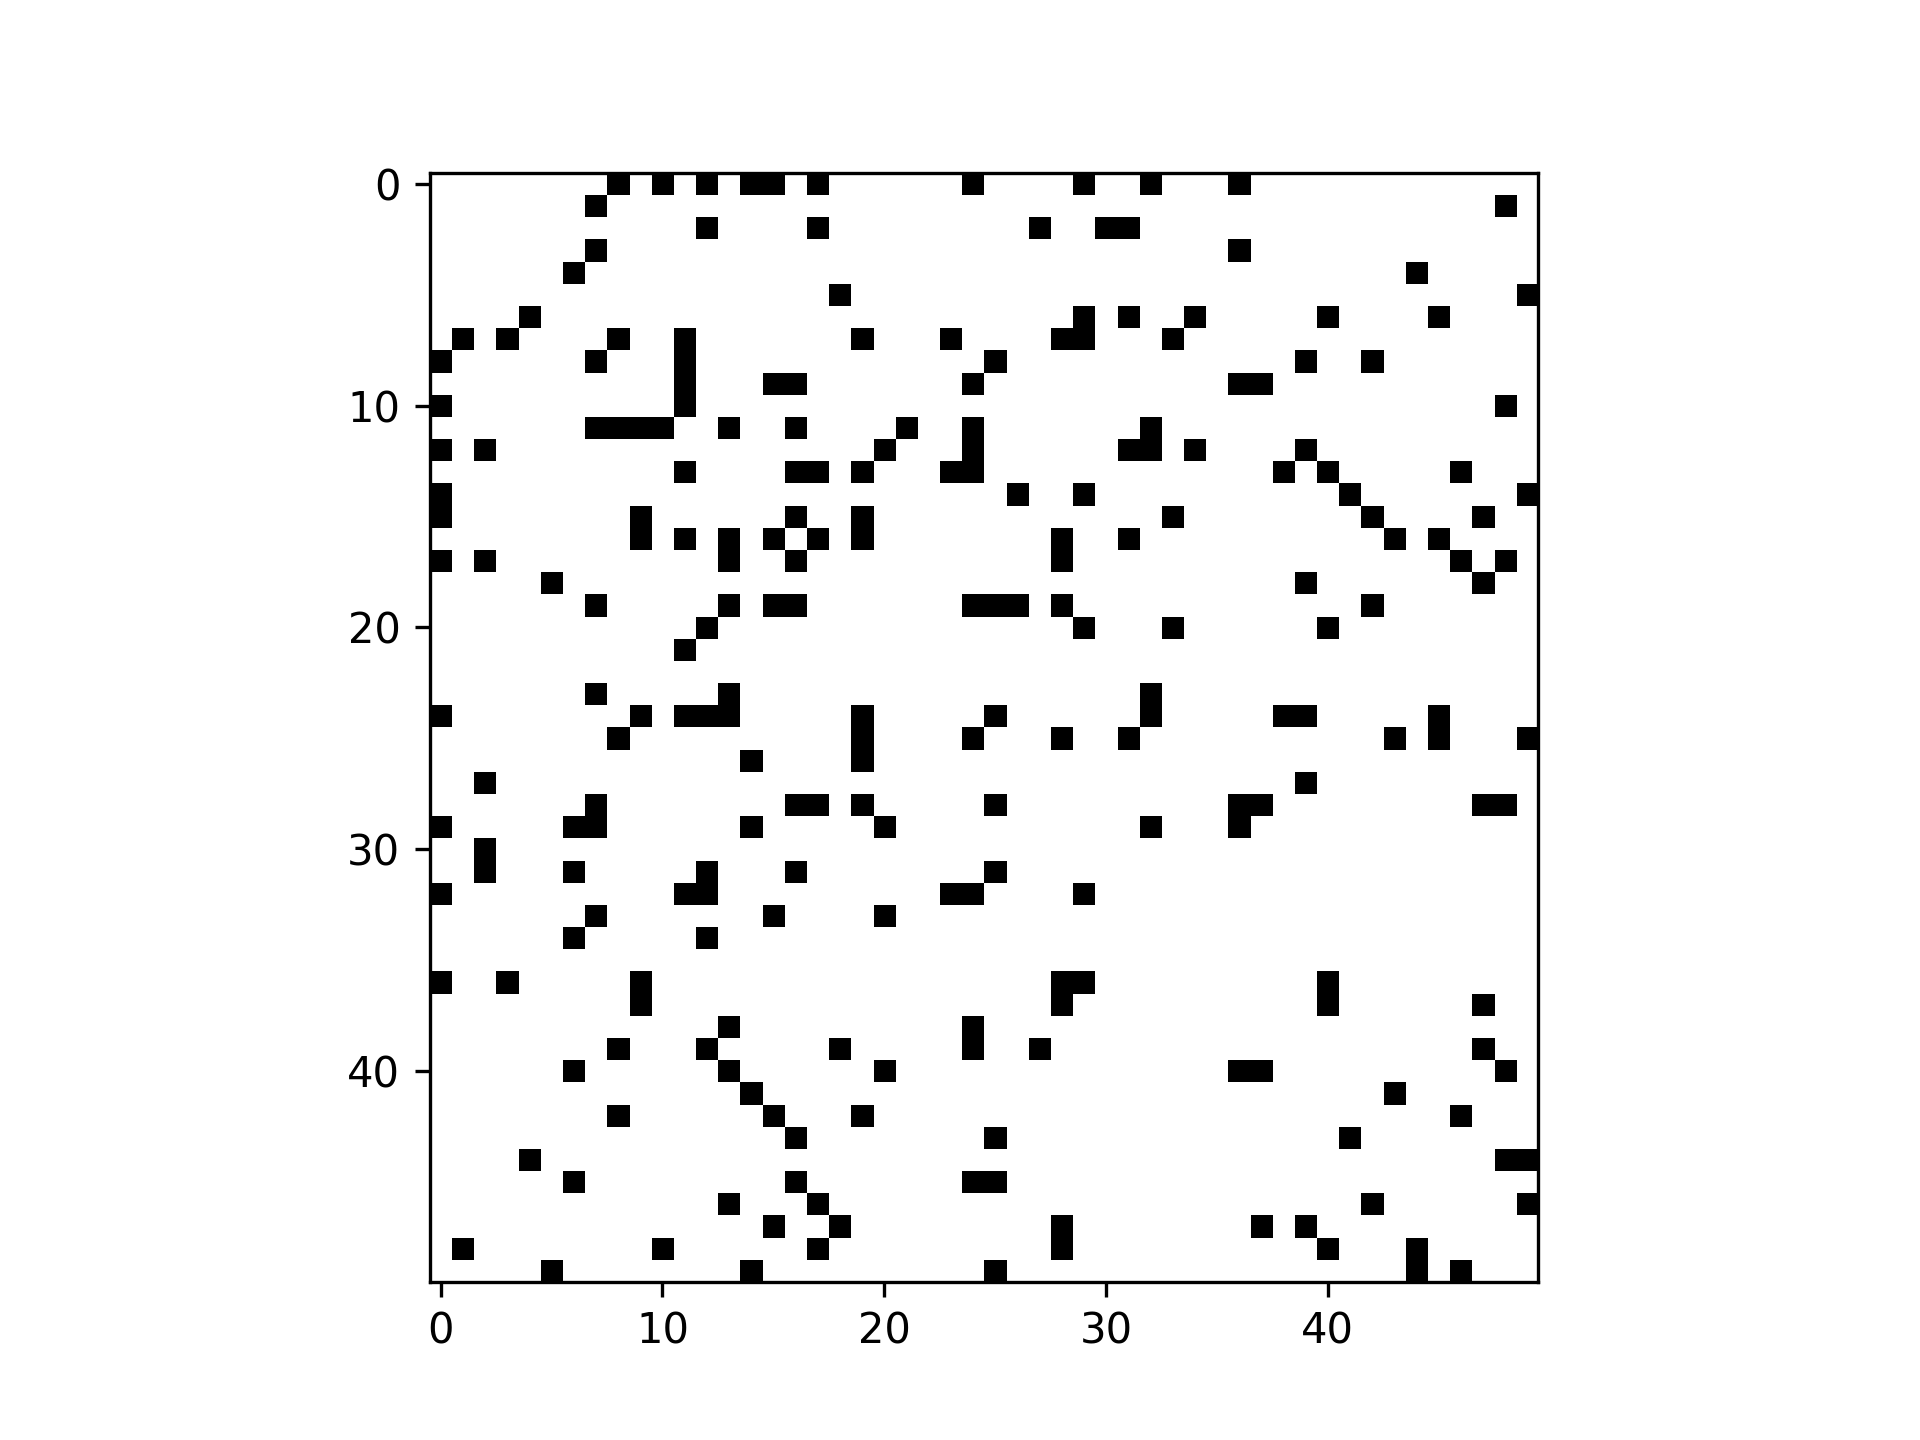

In [3]:
Y, X, probas_true = simulate_network_rw(
    n_nodes=50, n_time_steps=56, density=0.1, sigma=0.01,
    random_state=2398)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

0.19812363636363647


<IPython.core.display.Javascript object>


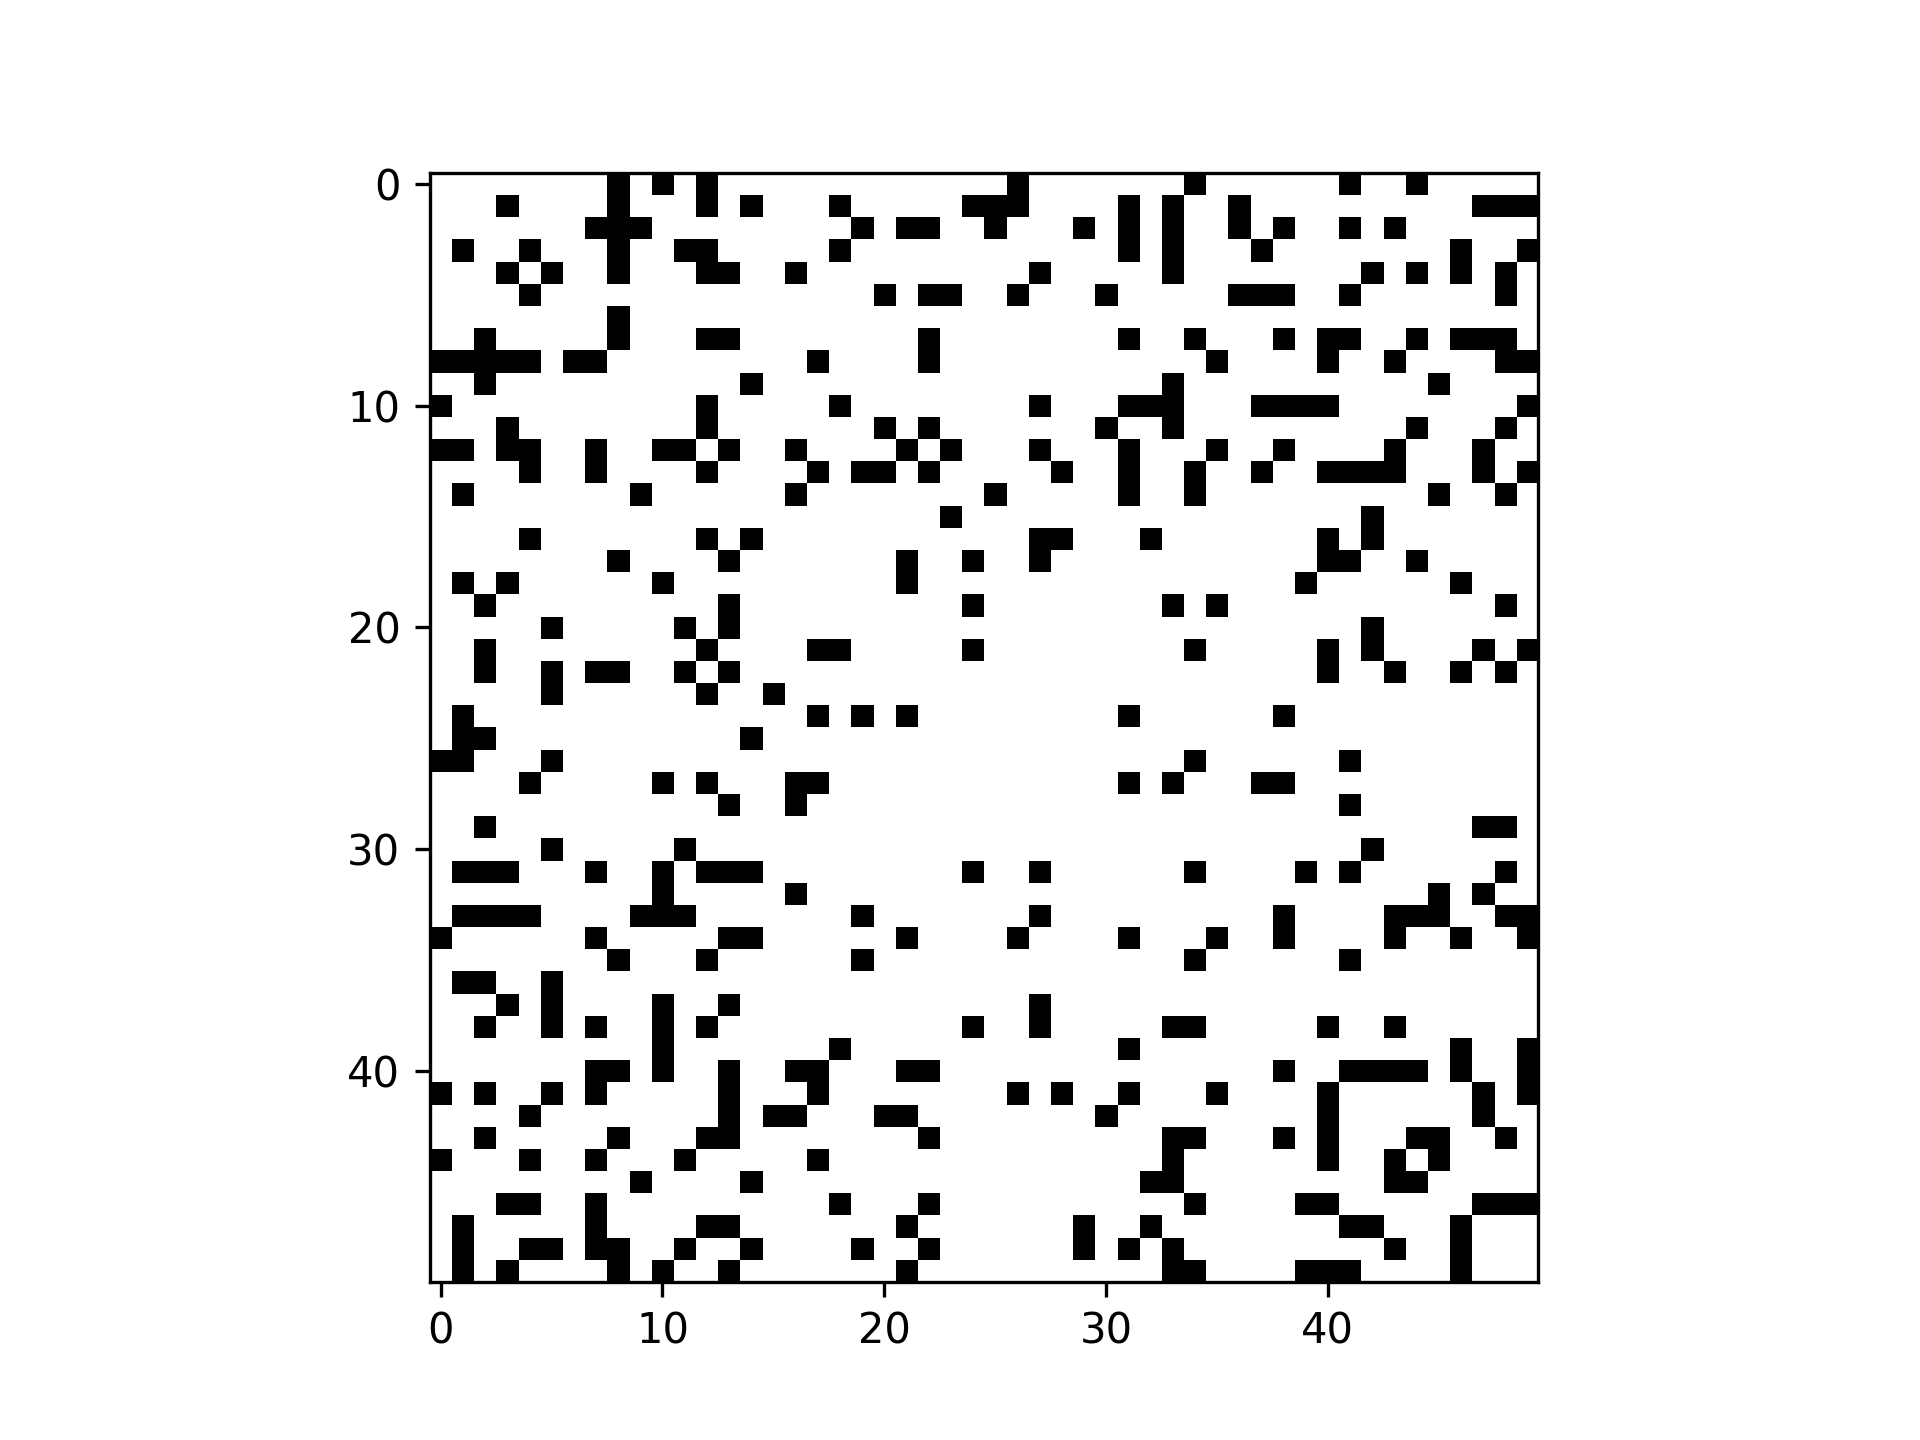

In [3]:
k_steps = 5
n_time_steps = 50

Y, X, probas_true = simulate_network_gp(
    n_nodes=50, n_time_steps=n_time_steps + k_steps, density=0.2, length_scale=2.5, random_state=4)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [130]:
np.sqrt((X[0,0] ** 2).sum())

0.4926735392608698

<IPython.core.display.Javascript object>


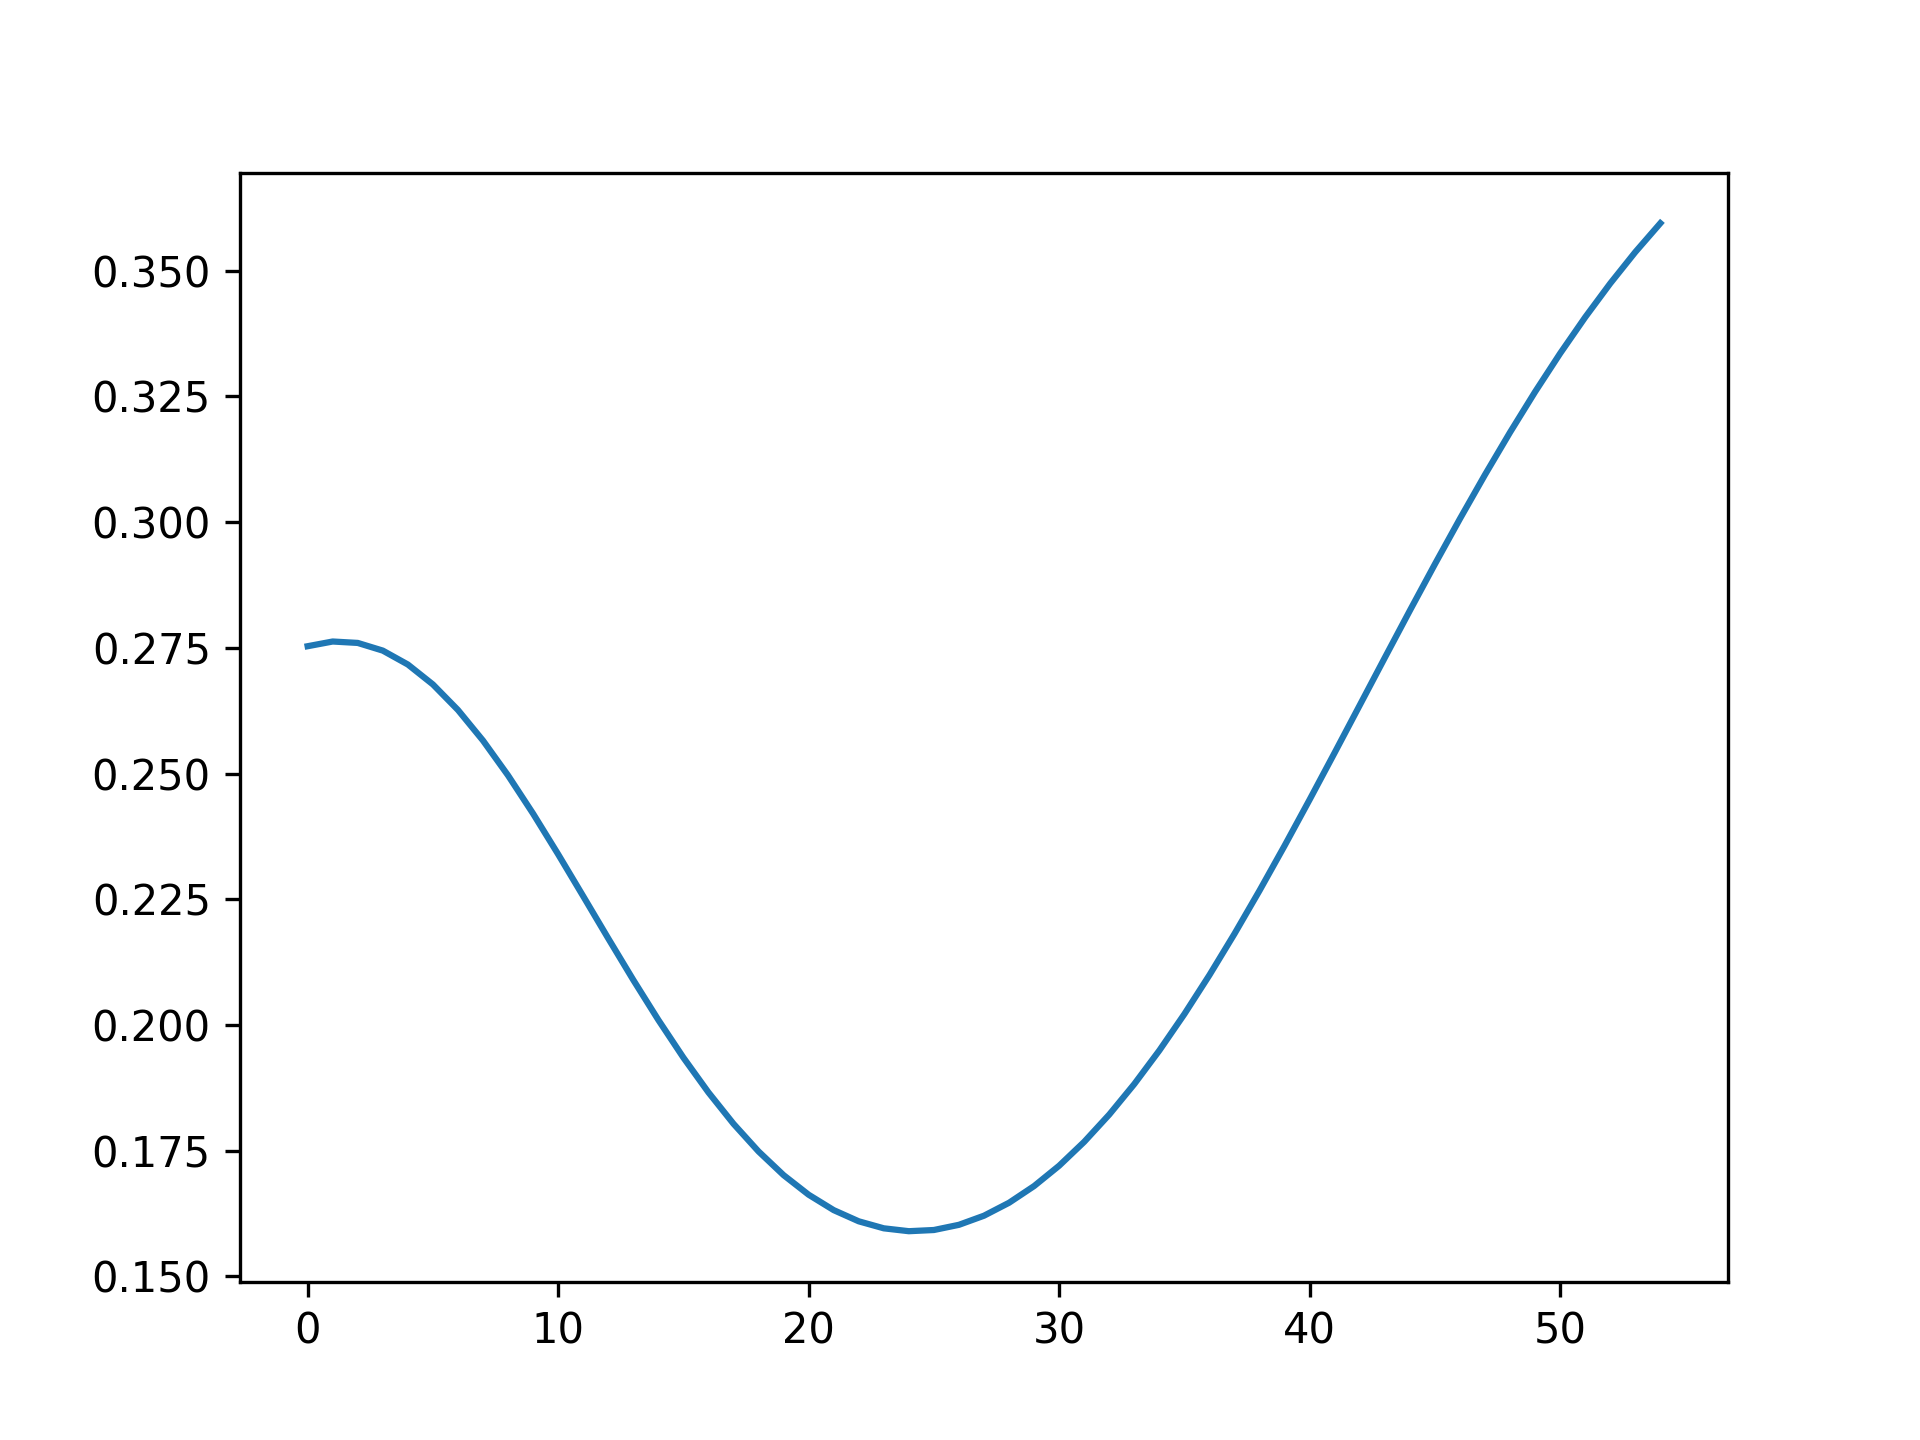

In [4]:
plt.plot(probas_true[:, 0, 10])

<IPython.core.display.Javascript object>


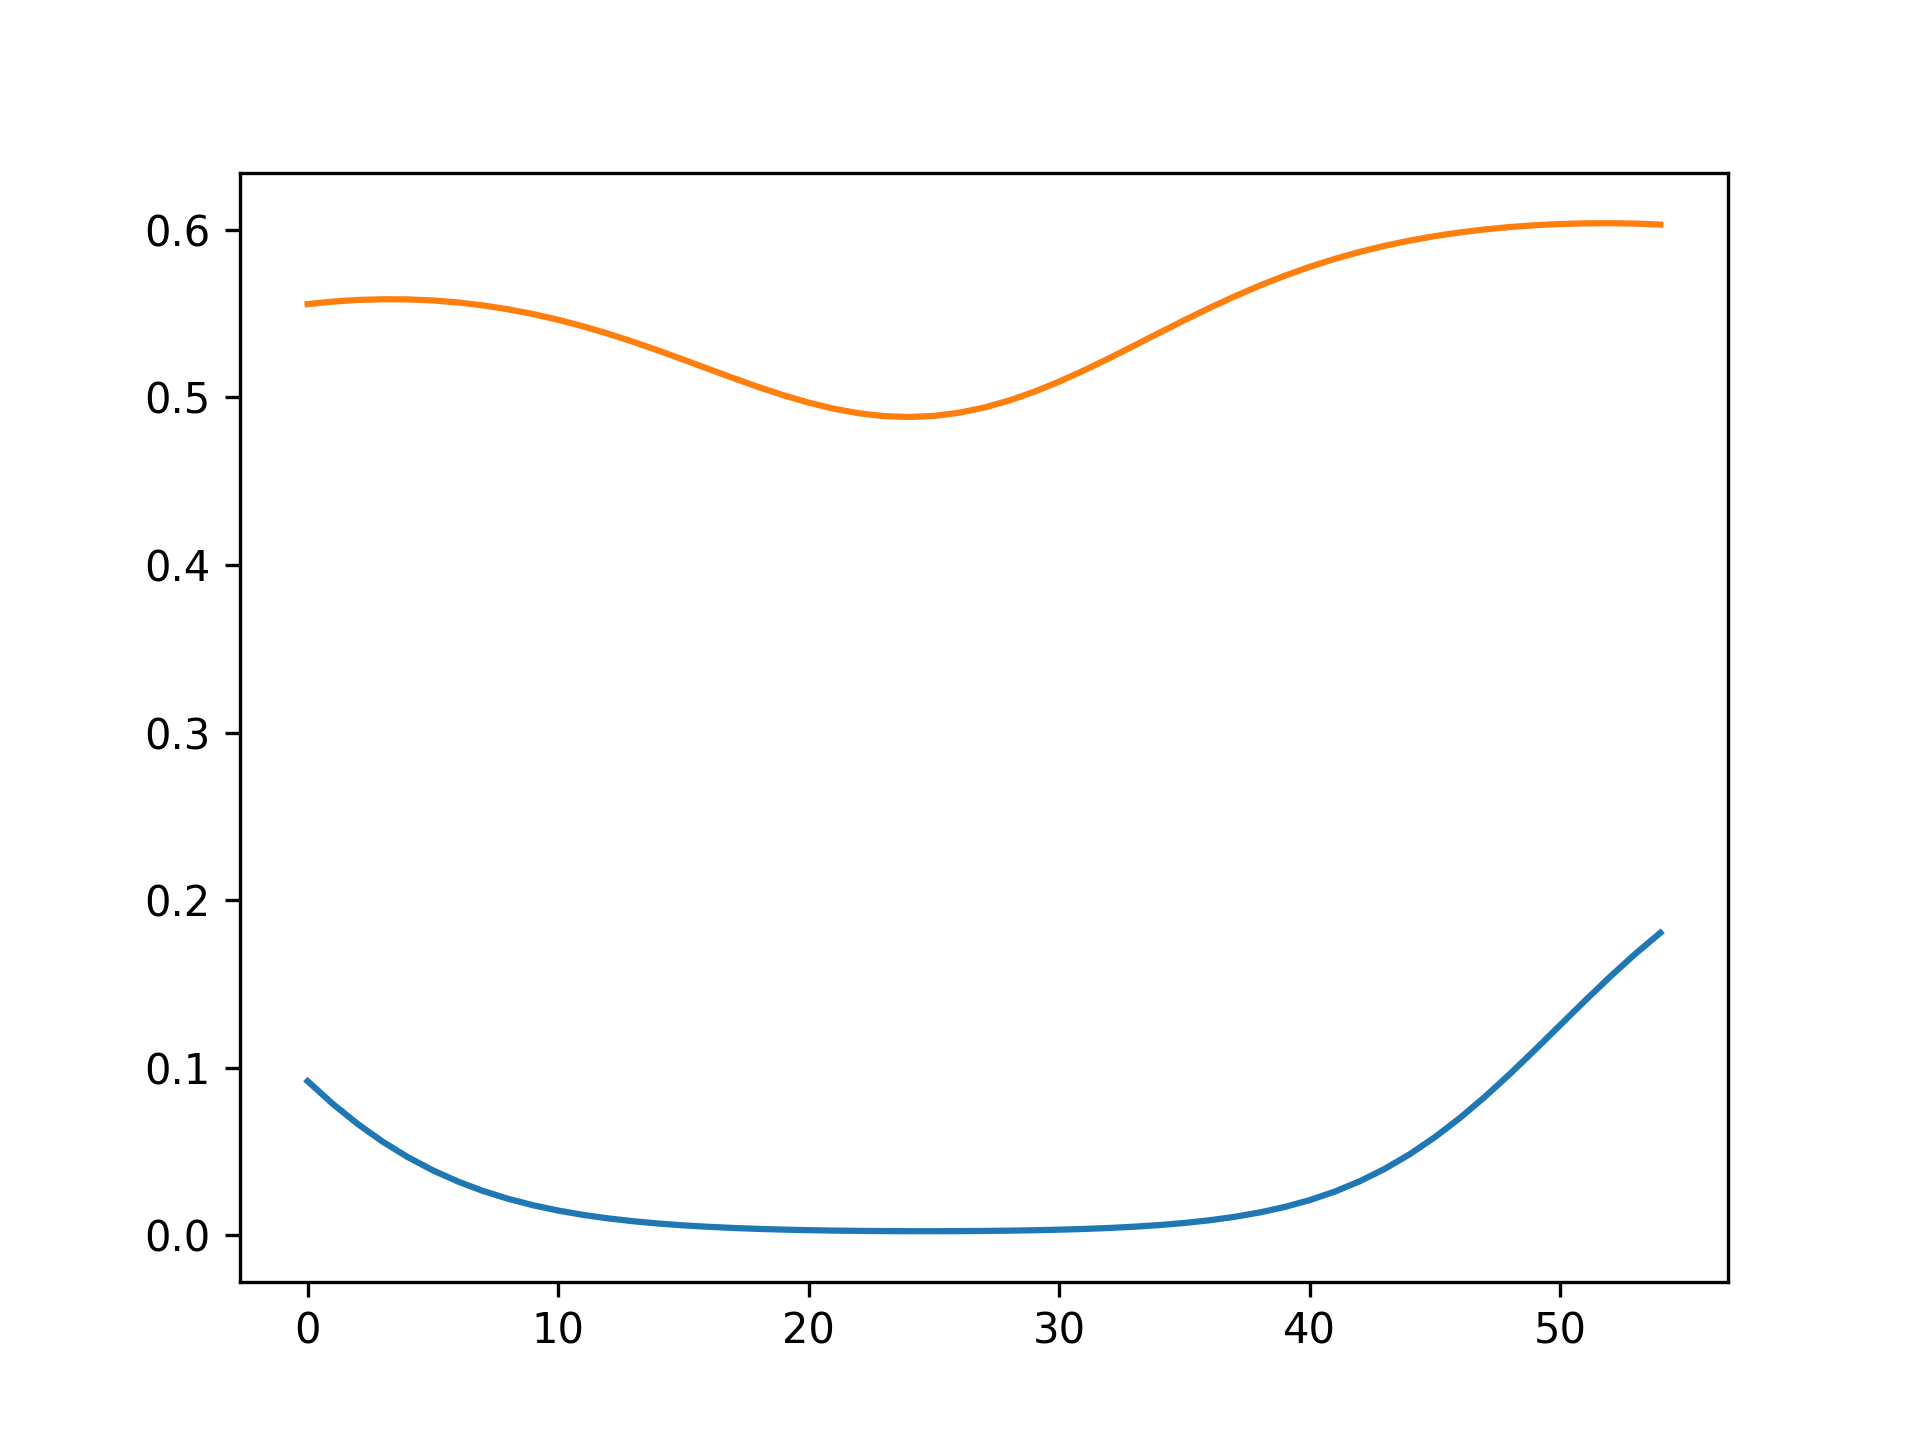

In [168]:
plt.plot(X[:, 1], '-')
#plt.plot(X[:, 2], '-')

In [5]:
rdpg = DynamicRDPG(n_features=2, rw_order=2, sample_scale=True, scale='auto')
rdpg.sample(Y[:-k_steps], n_burnin=200, n_samples=200)

100%|████████████████████████████████████████████████████████████████████████████| 400/400 [00:31<00:00, 12.74it/s]


<IPython.core.display.Javascript object>


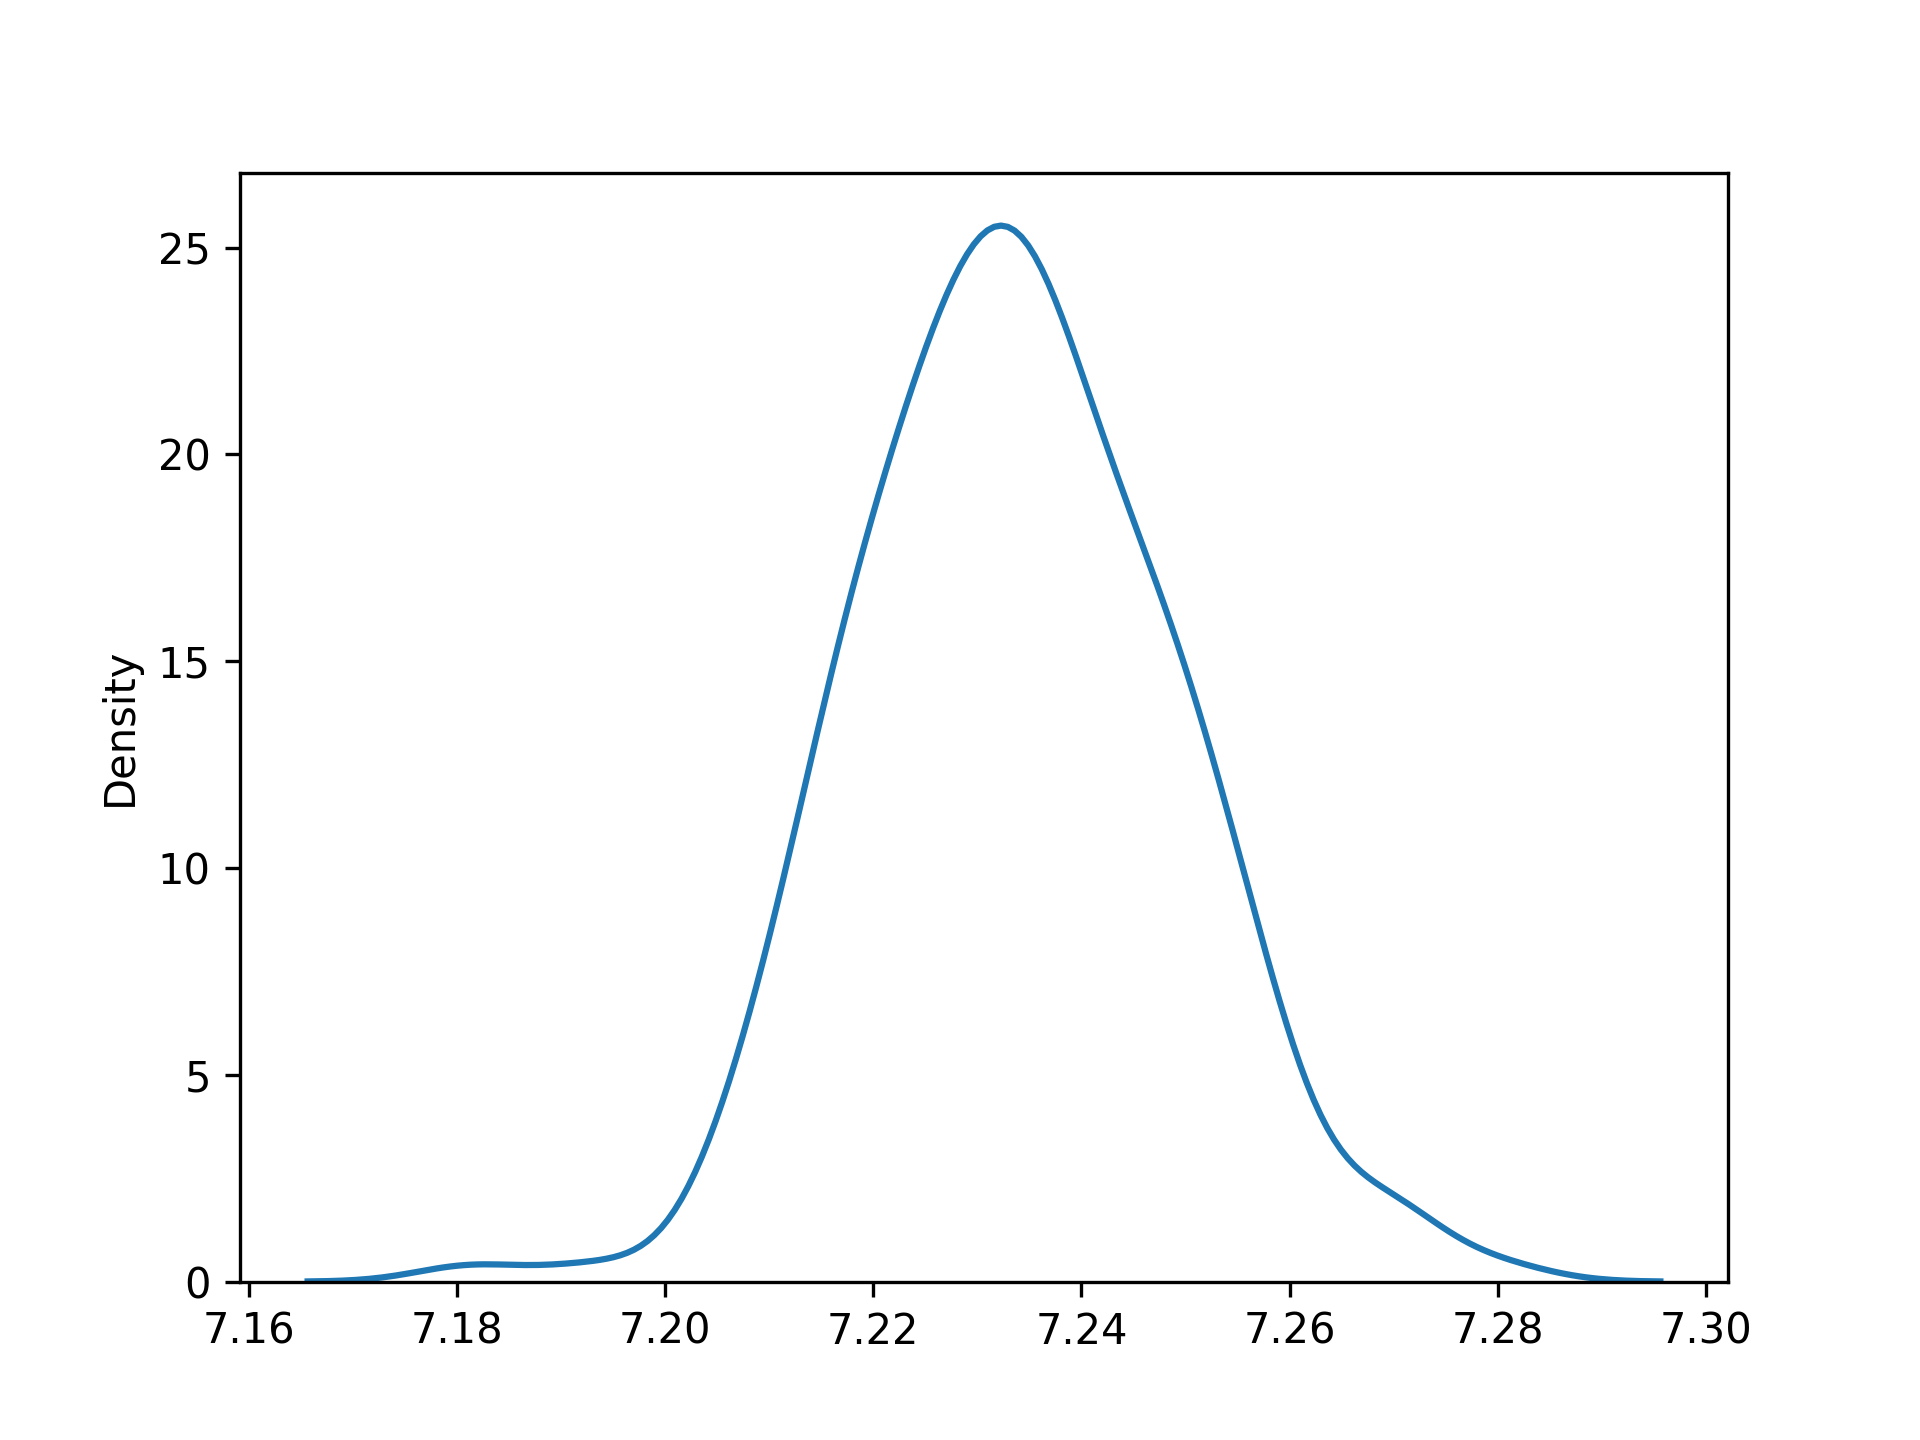

<Axes: ylabel='Density'>

In [134]:
sns.kdeplot(rdpg.samples_['scale'])

In [24]:
rdpg.waic()

5336.782871038111

In [6]:
rdpg.waic()

12010.41843206162

In [9]:
rdpg.waic()

12062.541011337868

In [36]:
rdpg.dic()

18584.31275010249

In [34]:
rdpg.dic()

18622.2208804648

In [27]:
rdpg.dic()

22680.358229007816

In [44]:
rdpg.waic()

18475.86310699238

In [5]:
n_params = np.prod(rdpg.X_.shape) + rdpg.sigma_.shape[0]
log_lik = -0.5 * np.sum((rdpg.y_vec_ - rdpg.probas_) ** 2)
-2 * log_lik + 2 * n_params

54256.64085536256

In [53]:
n_params = np.prod(rdpg.X_.shape) + rdpg.sigma_.shape[0]
log_lik = -0.5 * np.sum((rdpg.y_vec_ - rdpg.probas_) ** 2)
-2 * log_lik + 2 * n_params

63361.494273946686

In [55]:
n_params = np.prod(rdpg.X_.shape) + rdpg.sigma_.shape[0]
log_lik = -0.5 * np.sum((rdpg.y_vec_ - rdpg.probas_) ** 2)
-2 * log_lik + 2 * n_params

73343.58517306966

In [45]:
k_steps

5

<IPython.core.display.Javascript object>


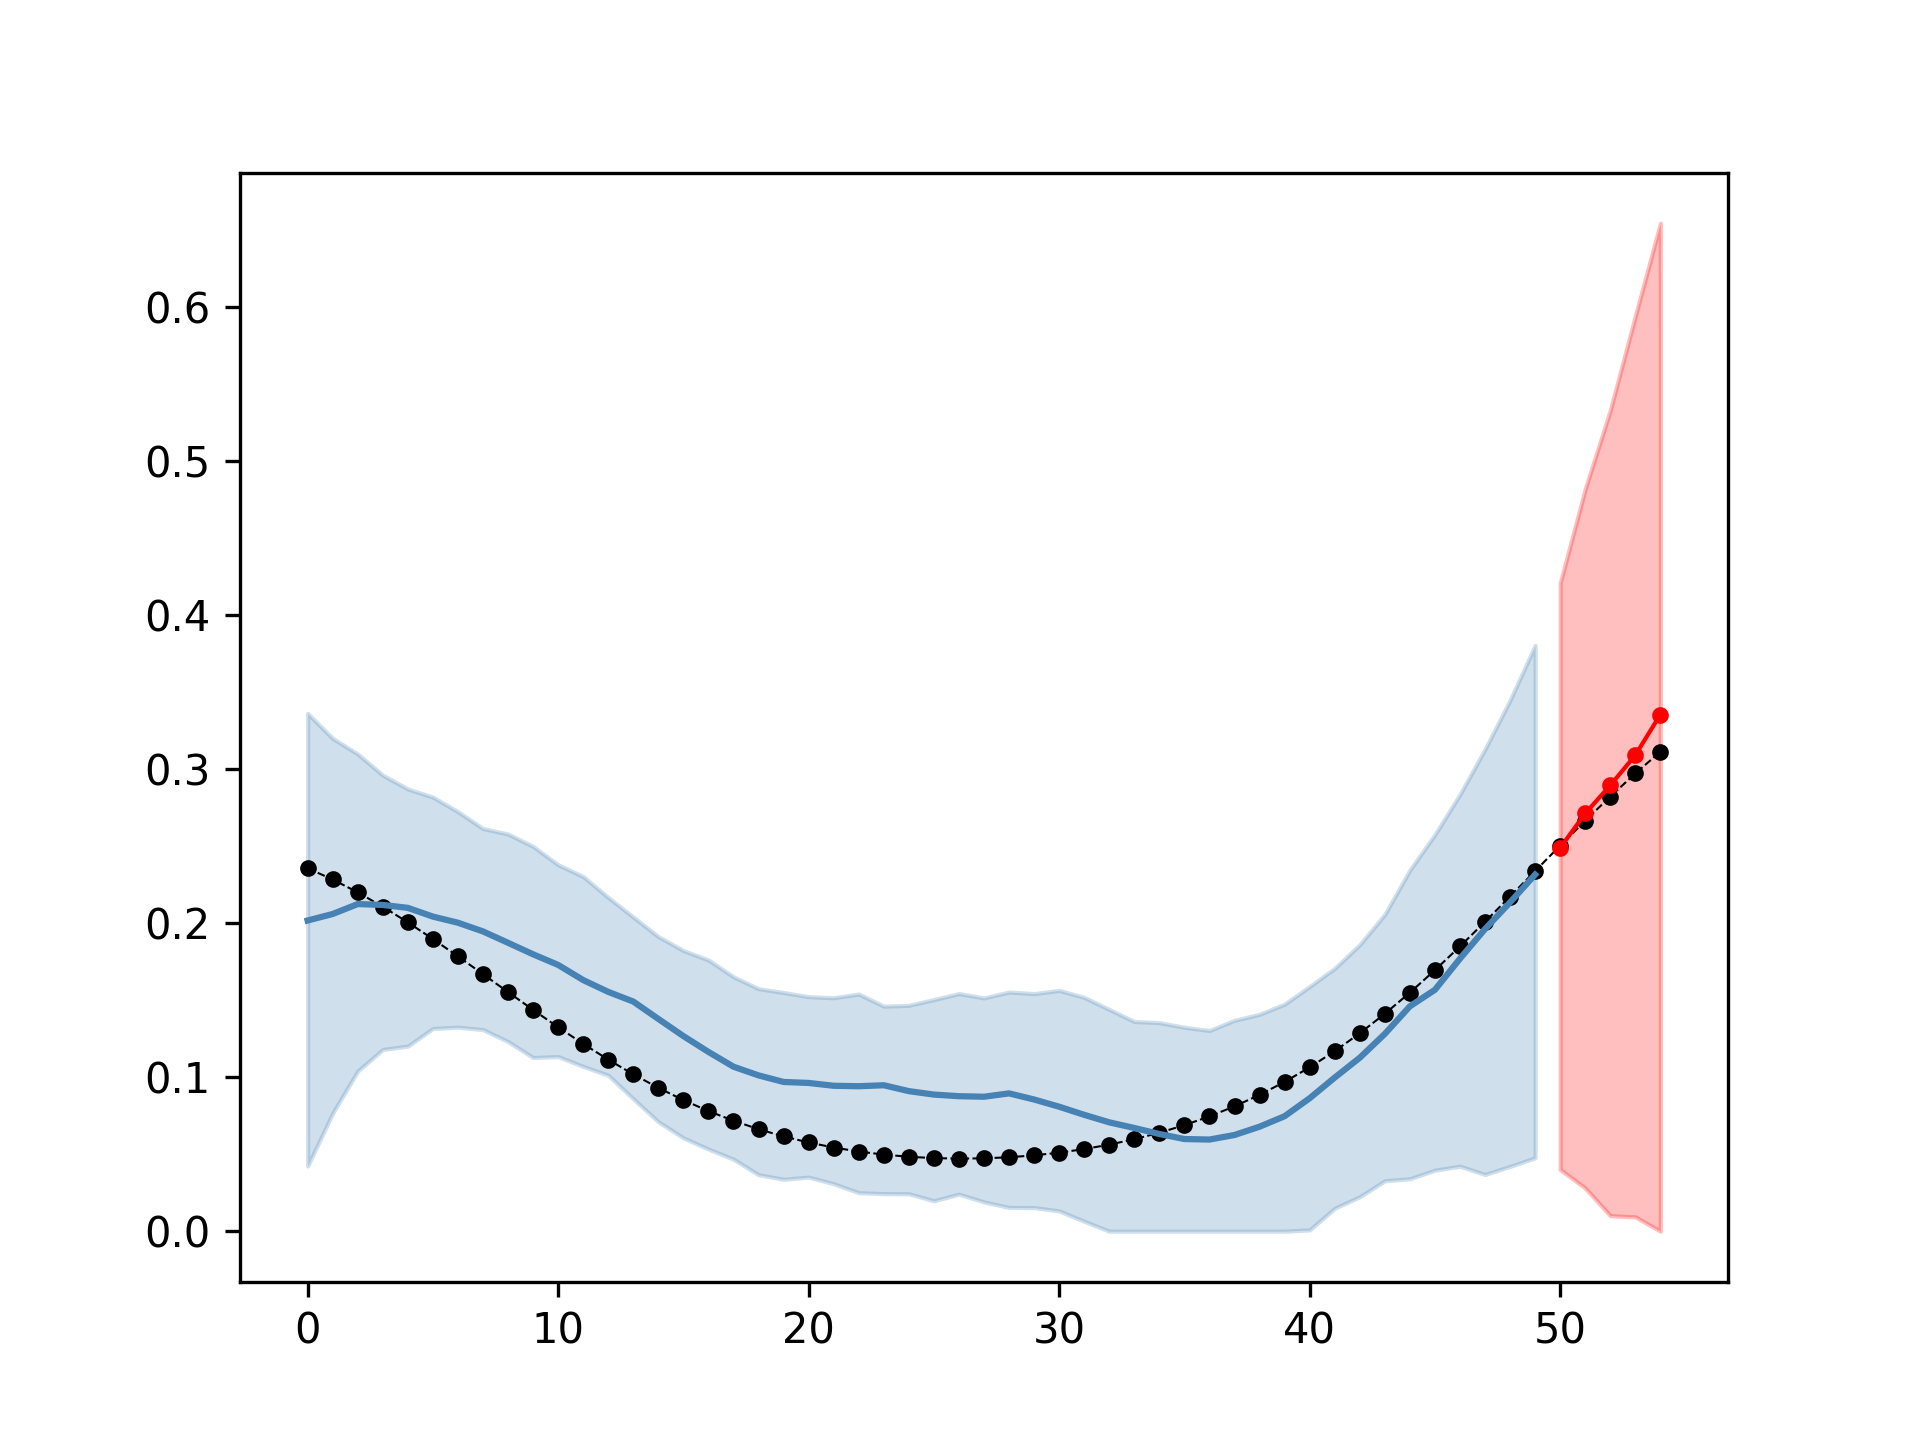

In [6]:
i, j = 1, 10

plt.plot(probas_true[:, i, j], 'k.--', lw=0.5)

n_time_steps, n_nodes, _ = rdpg.X_.shape
probas_pred = rdpg.predict(n_samples=1000)
cis = np.quantile(probas_pred[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
plt.plot(np.arange(n_time_steps), cis[1], color='steelblue')
plt.fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

probas_forecast = rdpg.forecast(k_steps=k_steps, n_samples=1000)
cis = np.quantile(probas_forecast[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
ts = np.arange(n_time_steps, n_time_steps + k_steps)
plt.plot(ts, cis[1], '.-', color='red', lw=1)
plt.fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
#plt.ylim(0, 1)

<IPython.core.display.Javascript object>


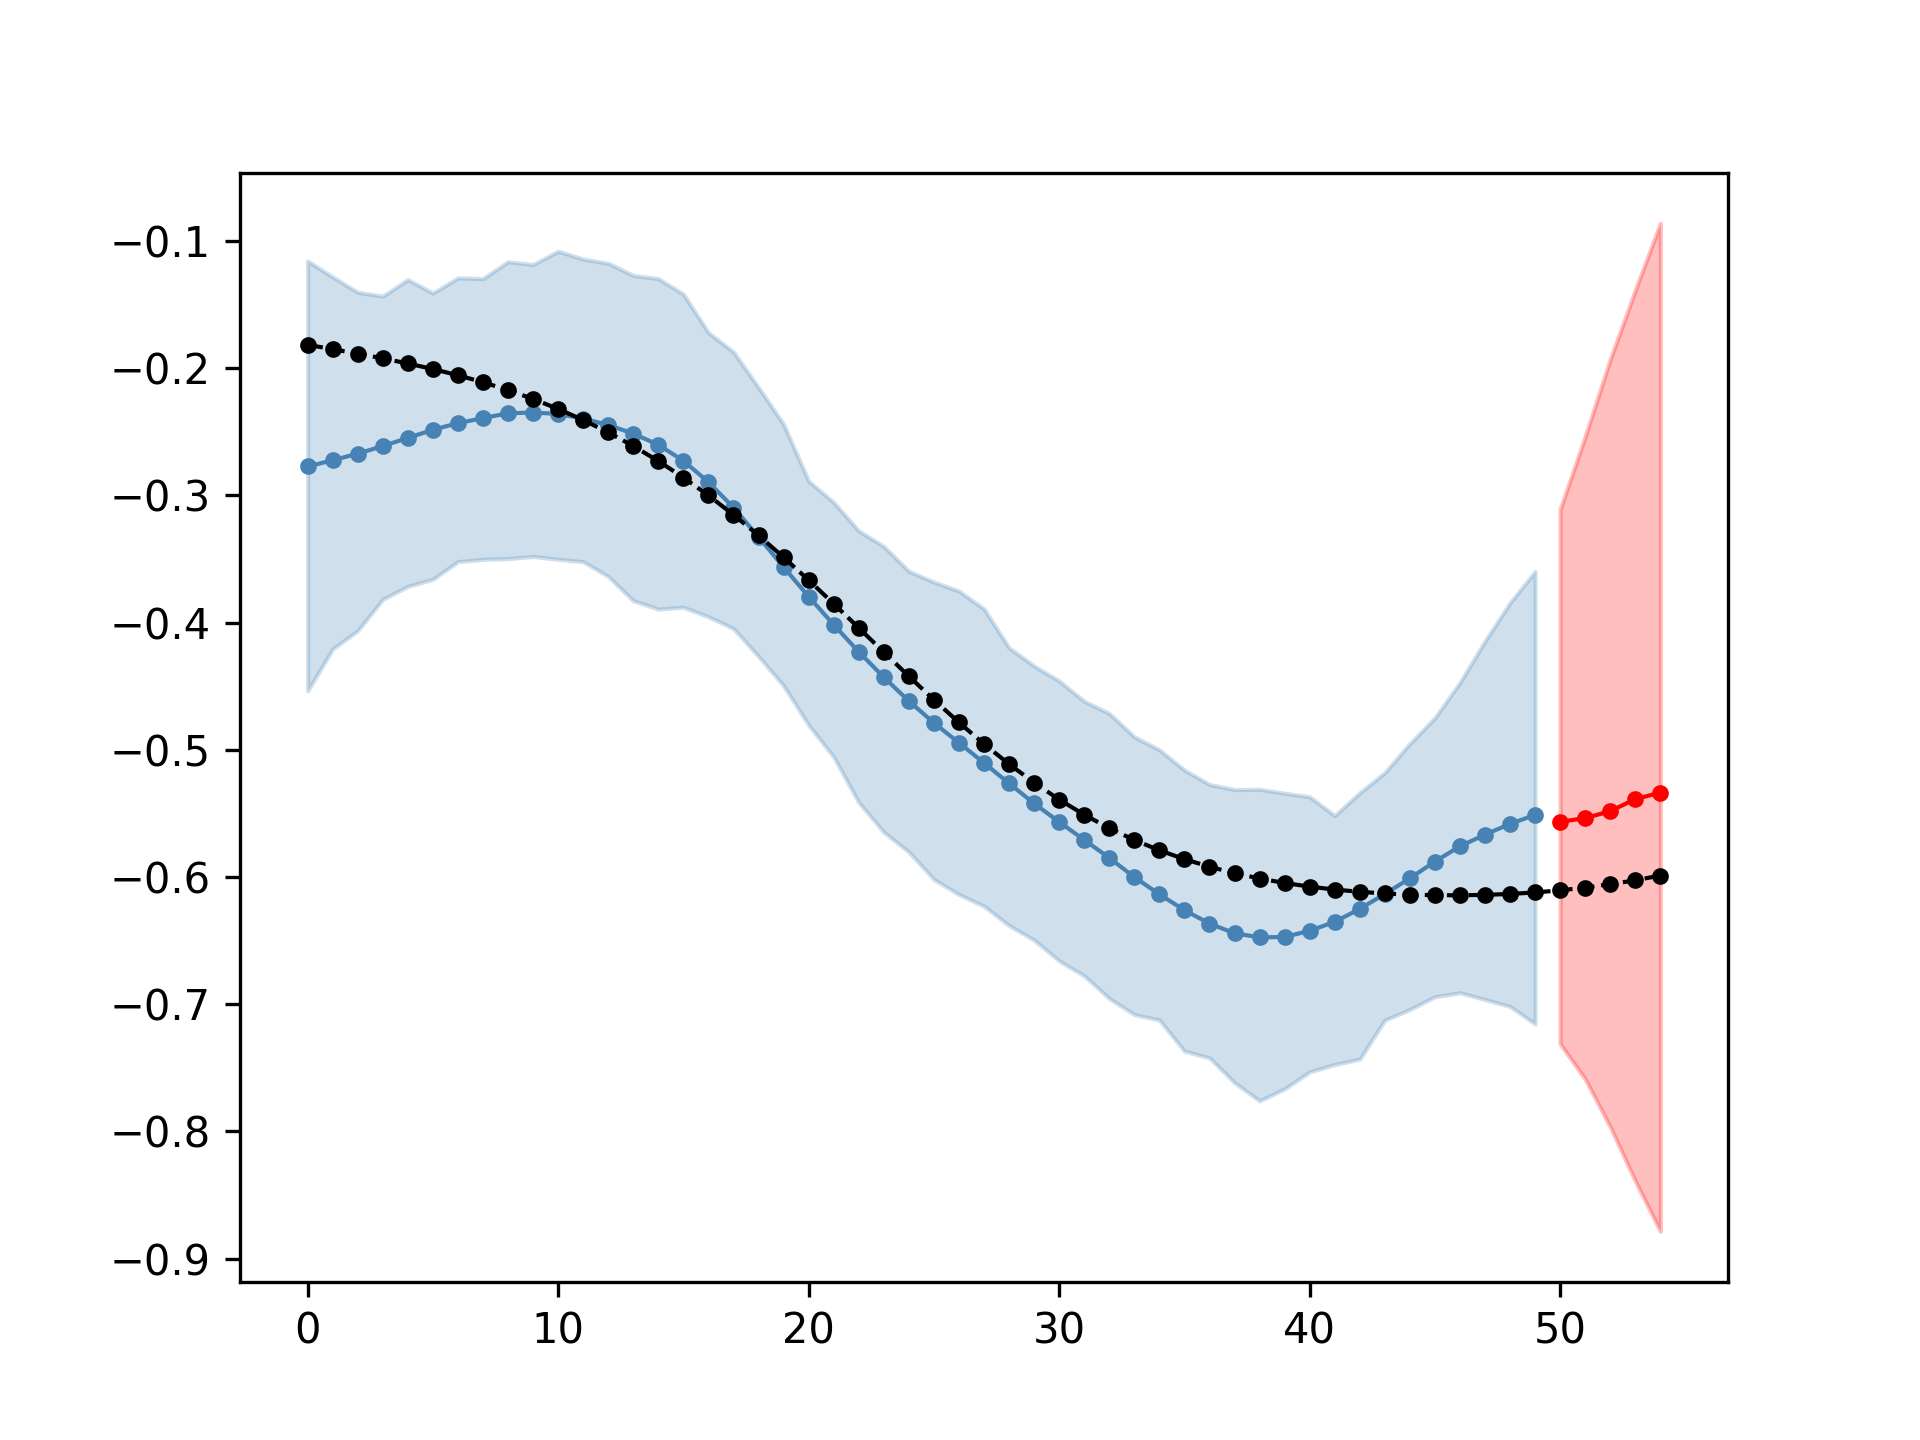

In [7]:
from scipy.linalg import orthogonal_procrustes

idx = 27


#print(np.sqrt(dase.sigma_[idx]))
X_est = rdpg.X_.copy()#np.mean(dase.samples_['X'], axis=0)
X_true = X.copy()
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_true[t], X_est[t])
    X_true[t] = X_true[t] @ R

#for t in range(len(Y)-k_steps, len(Y)):
#    R, _ = orthogonal_procrustes(X_true[t], X_est[-1])
#    X_true[t] = X_true[t] @ R
    

cis = np.quantile(rdpg.samples_['X'][:, :, idx], q=[0.025, 0.975], axis=0)
#plt.plot(X_est[:, idx, 1], '-', color='darkorange', lw=2)
plt.plot(X_est[:, idx, 0], '.-', color='steelblue', lw=1)
#plt.fill_between(np.arange(len(Y)-1), cis[0, :, 1], cis[1, :, 1], color='darkorange', alpha=0.25)
plt.fill_between(np.arange(len(Y)-k_steps), cis[0, :, 0], cis[1, :, 0], color='steelblue', alpha=0.25)

samples = rdpg.forecast_positions(k_steps=k_steps, n_samples=1000)
cis = np.quantile(samples, q=[0.025,0.5, 0.975], axis=0)
X_forecast = cis[1]
for k, t in enumerate(range(len(Y)-k_steps, len(Y))):
    R, _ = orthogonal_procrustes(X_true[t], X_forecast[k])
    X_true[t] = X_true[t] @ R
    
plt.plot(np.arange(X_est.shape[0], X_est.shape[0] + k_steps), X_forecast[:, idx, 0], '.-', color='red', lw=1)
plt.fill_between(np.arange(X_est.shape[0], X_est.shape[0] + k_steps), 
                 cis[0, :, idx, 0], cis[2, :, idx, 0], 
                 color='red', alpha=0.25)

plt.plot(X_true[:, idx, 0], '.--', lw=1, color='k')

<IPython.core.display.Javascript object>


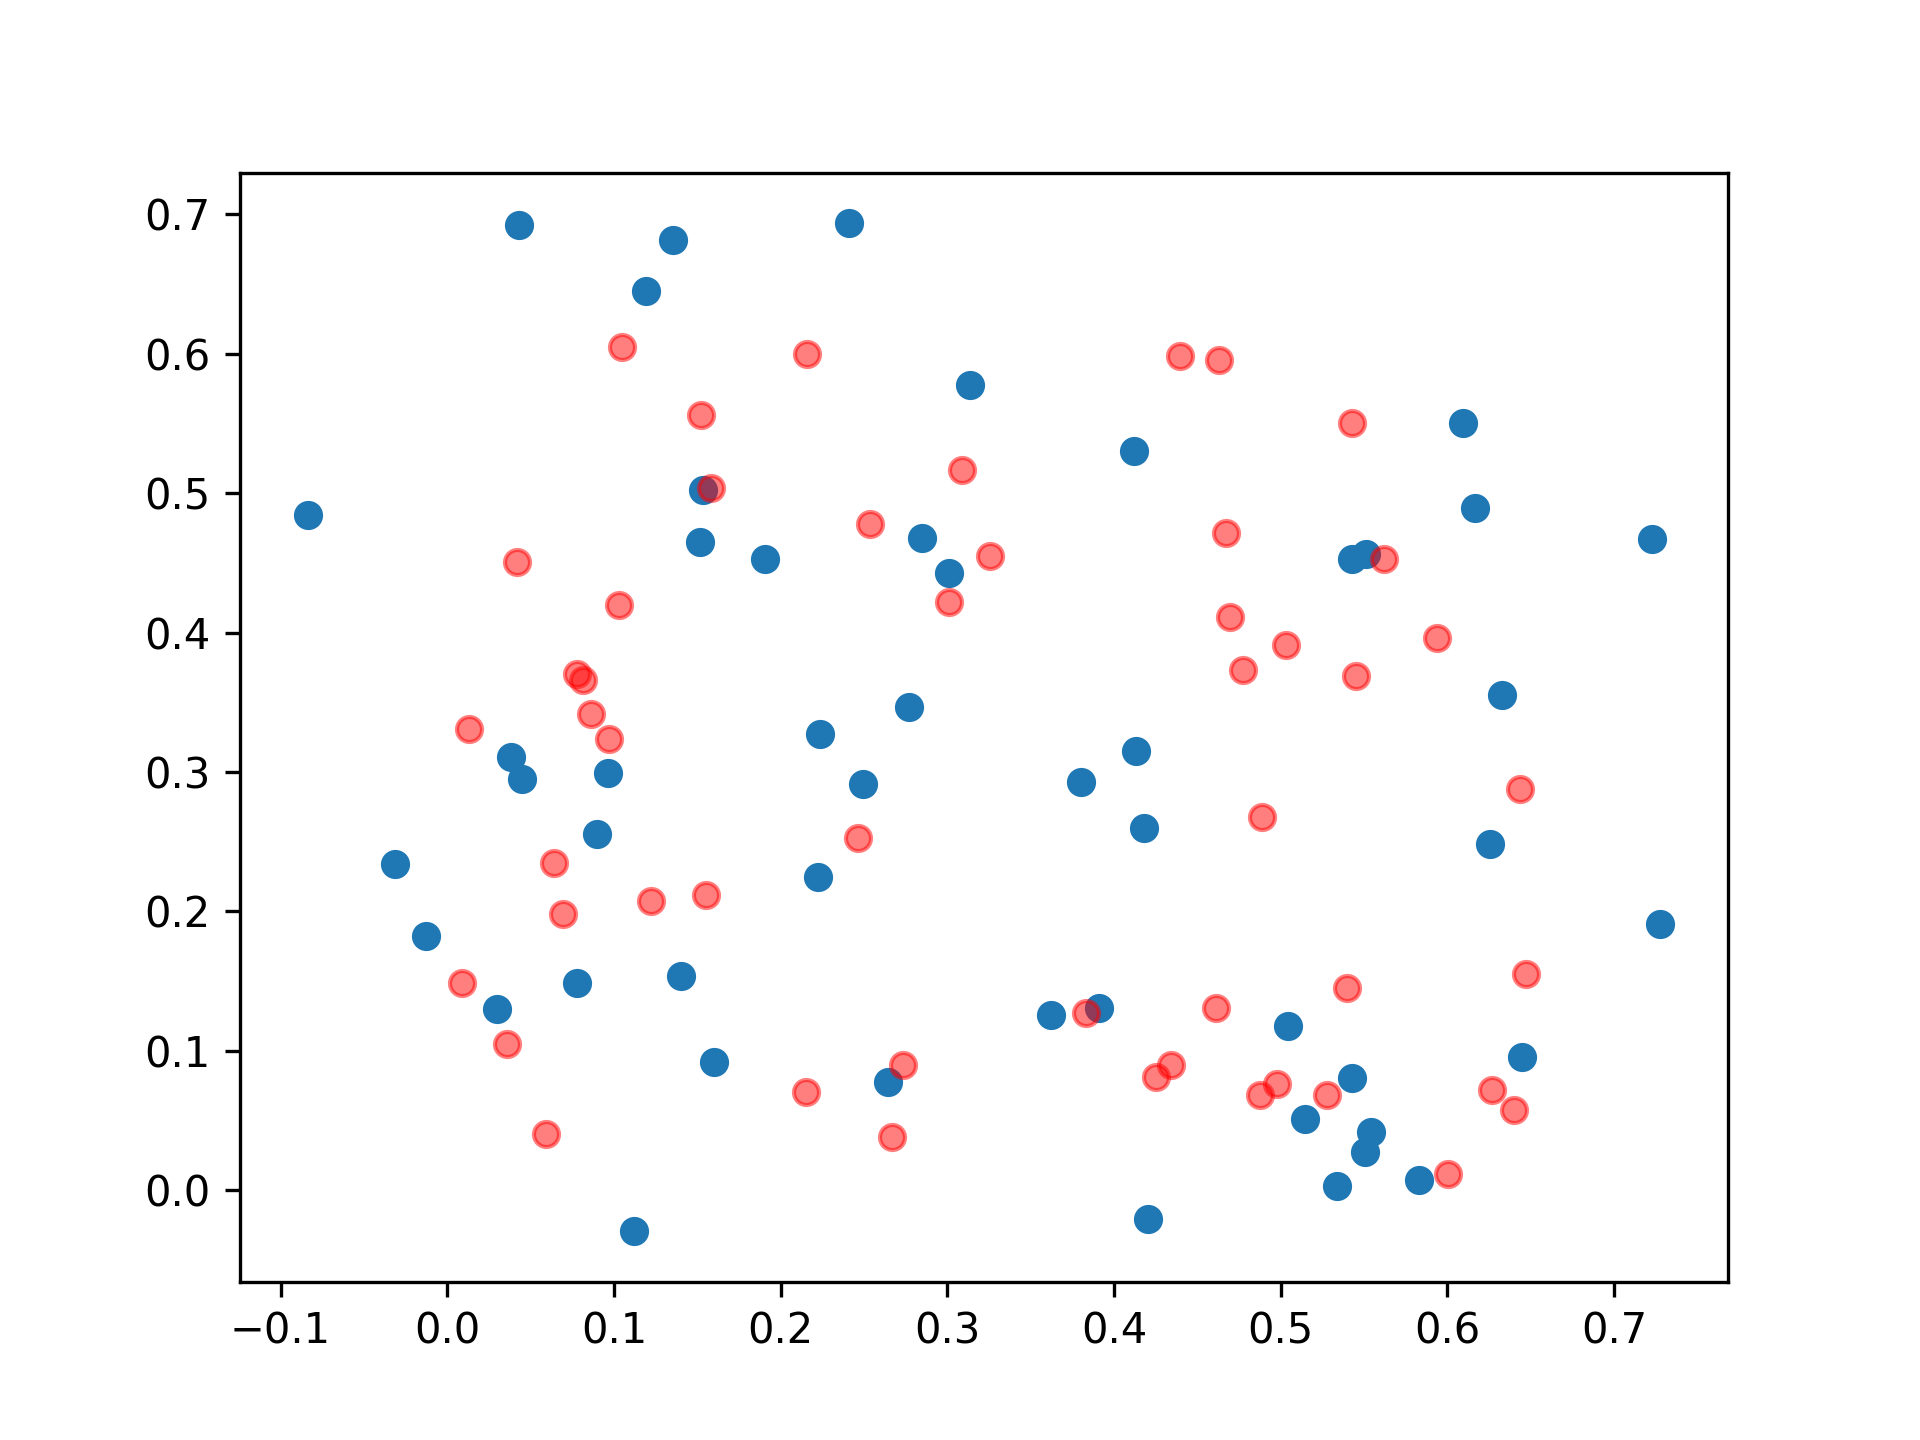

0.7116524596711965


0.009561737604182444

In [8]:
from scipy.linalg import orthogonal_procrustes
from sklearn.metrics import roc_auc_score

t = -1
X_rdpg = rdpg.X_[t]
R, _ = orthogonal_procrustes(X_rdpg, X[t])
X_rdpg = X_rdpg @ R
plt.scatter(X_rdpg[:, 0], X_rdpg[:, 1])
plt.scatter(X[t][:, 0], X[t][:, 1], c='red', alpha=0.5)

subdiag = np.tril_indices_from(Y[t], k=-1)

print(roc_auc_score(Y[t][subdiag], rdpg.probas_[t]))
np.mean((X_rdpg - X[t]) ** 2)

In [9]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
print(rdpg.auc_)
r_rdpg = np.mean((X_pred - X[:-k_steps]) ** 2)
r_rdpg

0.7184142468216881


0.0033601105456346355

In [10]:
import scipy.sparse as sp
from sklearn.decomposition import TruncatedSVD

# unfolded adjacency spectral embedding
n_nodes, _ = Y[0].shape
A = sp.csr_array(np.hstack([Yt.toarray() for Yt in Y[:-k_steps]]))
u, s, vh= sp.linalg.svds(A, k=2)
X_uase = (vh.T[:, ::-1] * np.sqrt(s)[::-1]).reshape(len(Y[:-k_steps]), n_nodes, 2)

for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_uase[t], X[t])
    X_uase[t] = X_uase[t] @ R


np.mean((X_uase - X[:-k_steps]) ** 2)

0.06680237498861517

In [12]:
from graspologic.embed import AdjacencySpectralEmbed as ASE
from dynrdpg.dynrdpg import calculate_auc

proba_ase= []
X_ase = []
for t in range(len(Y)-k_steps):
    subdiag = np.tril_indices(Y[t].shape[0], k=-1)
    ase = ASE(n_components=2)
    X_ase.append(ase.fit_transform(Y[t]))
    R, _ = orthogonal_procrustes(X_ase[t], X[t])
    X_ase[t] = X_ase[t] @ R
    proba_ase.append(np.clip((X_ase[t] @ X_ase[t].T)[subdiag], 0, 1))

X_ase = np.stack(X_ase)
proba_ase = np.stack(proba_ase)

print(calculate_auc(rdpg.y_vec_, proba_ase))
r_ase = np.mean((X_ase - X[:-k_steps]) ** 2)# / np.mean(X ** 2))
r_ase

0.6545845557938794


/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


0.07102788313204479

In [13]:
from graspologic.embed import MultipleASE as MASE

X_mase = MASE(n_components=2).fit_transform(Y[:-k_steps])
X_aligned = []
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_mase, X[t])
    X_aligned.append(X_mase @ R)
X_aligned = np.stack(X_aligned)

np.mean((X_aligned - X[:-k_steps]) ** 2)

0.08105041917468715

In [14]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-k_steps])
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_omni[t], X[t])
    X_omni[t] = X_omni[t] @ R
    
np.mean((X_omni - X[:-k_steps]) ** 2)

0.01245756225053532

## Forecast

In [26]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, n_samples=1000).mean(axis=0)[-1][subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2) / np.mean(probas_true[-1][subdiag] ** 2))

0.7087520538867254
0.43539240933199425
0.09981579784615106


In [16]:
subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = Y[-k_steps].toarray()[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
log_loss(y_true, y_pred)
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2) / np.mean(probas_true[-1][subdiag] ** 2))

0.5524002106084951
2.5875236458950823


In [17]:
from graspologic.embed import AdjacencySpectralEmbed as ASE

ase = ASE(n_components=2)
X_ase = ase.fit_transform(Y[-k_steps])
y_pred = np.clip(X_ase @ X_ase.T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2) / np.mean(probas_true[-1][subdiag] ** 2))

0.662642864275534
0.8098617001850786
0.37585790998527263


/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


In [18]:
from graspologic.embed import OmnibusEmbed as OMNI

omni = OMNI(n_components=2)
X_omni = omni.fit_transform(Y[:-k_steps])
y_pred = np.clip(X_omni[-1] @ X_omni[-1].T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2) / np.mean(probas_true[-1][subdiag] ** 2))

0.667490490844885
0.4698706302951727
0.1281340159614437


In [27]:
from graspologic.embed import MultipleASE as MASE
from sklearn.metrics import roc_auc_score

subdiag = np.tril_indices(Y[0].shape[0], k=-1)
mase = MASE(n_components=2).fit(Y[:-k_steps])
X_mase = mase.latent_left_
R = mase.scores_[-1]
y_pred_mase = np.clip(X_mase @ R @ X_mase.T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred_mase) ** 2) / np.mean(probas_true[-1][subdiag] ** 2))

0.7087520538867254
0.225987155005459


<IPython.core.display.Javascript object>


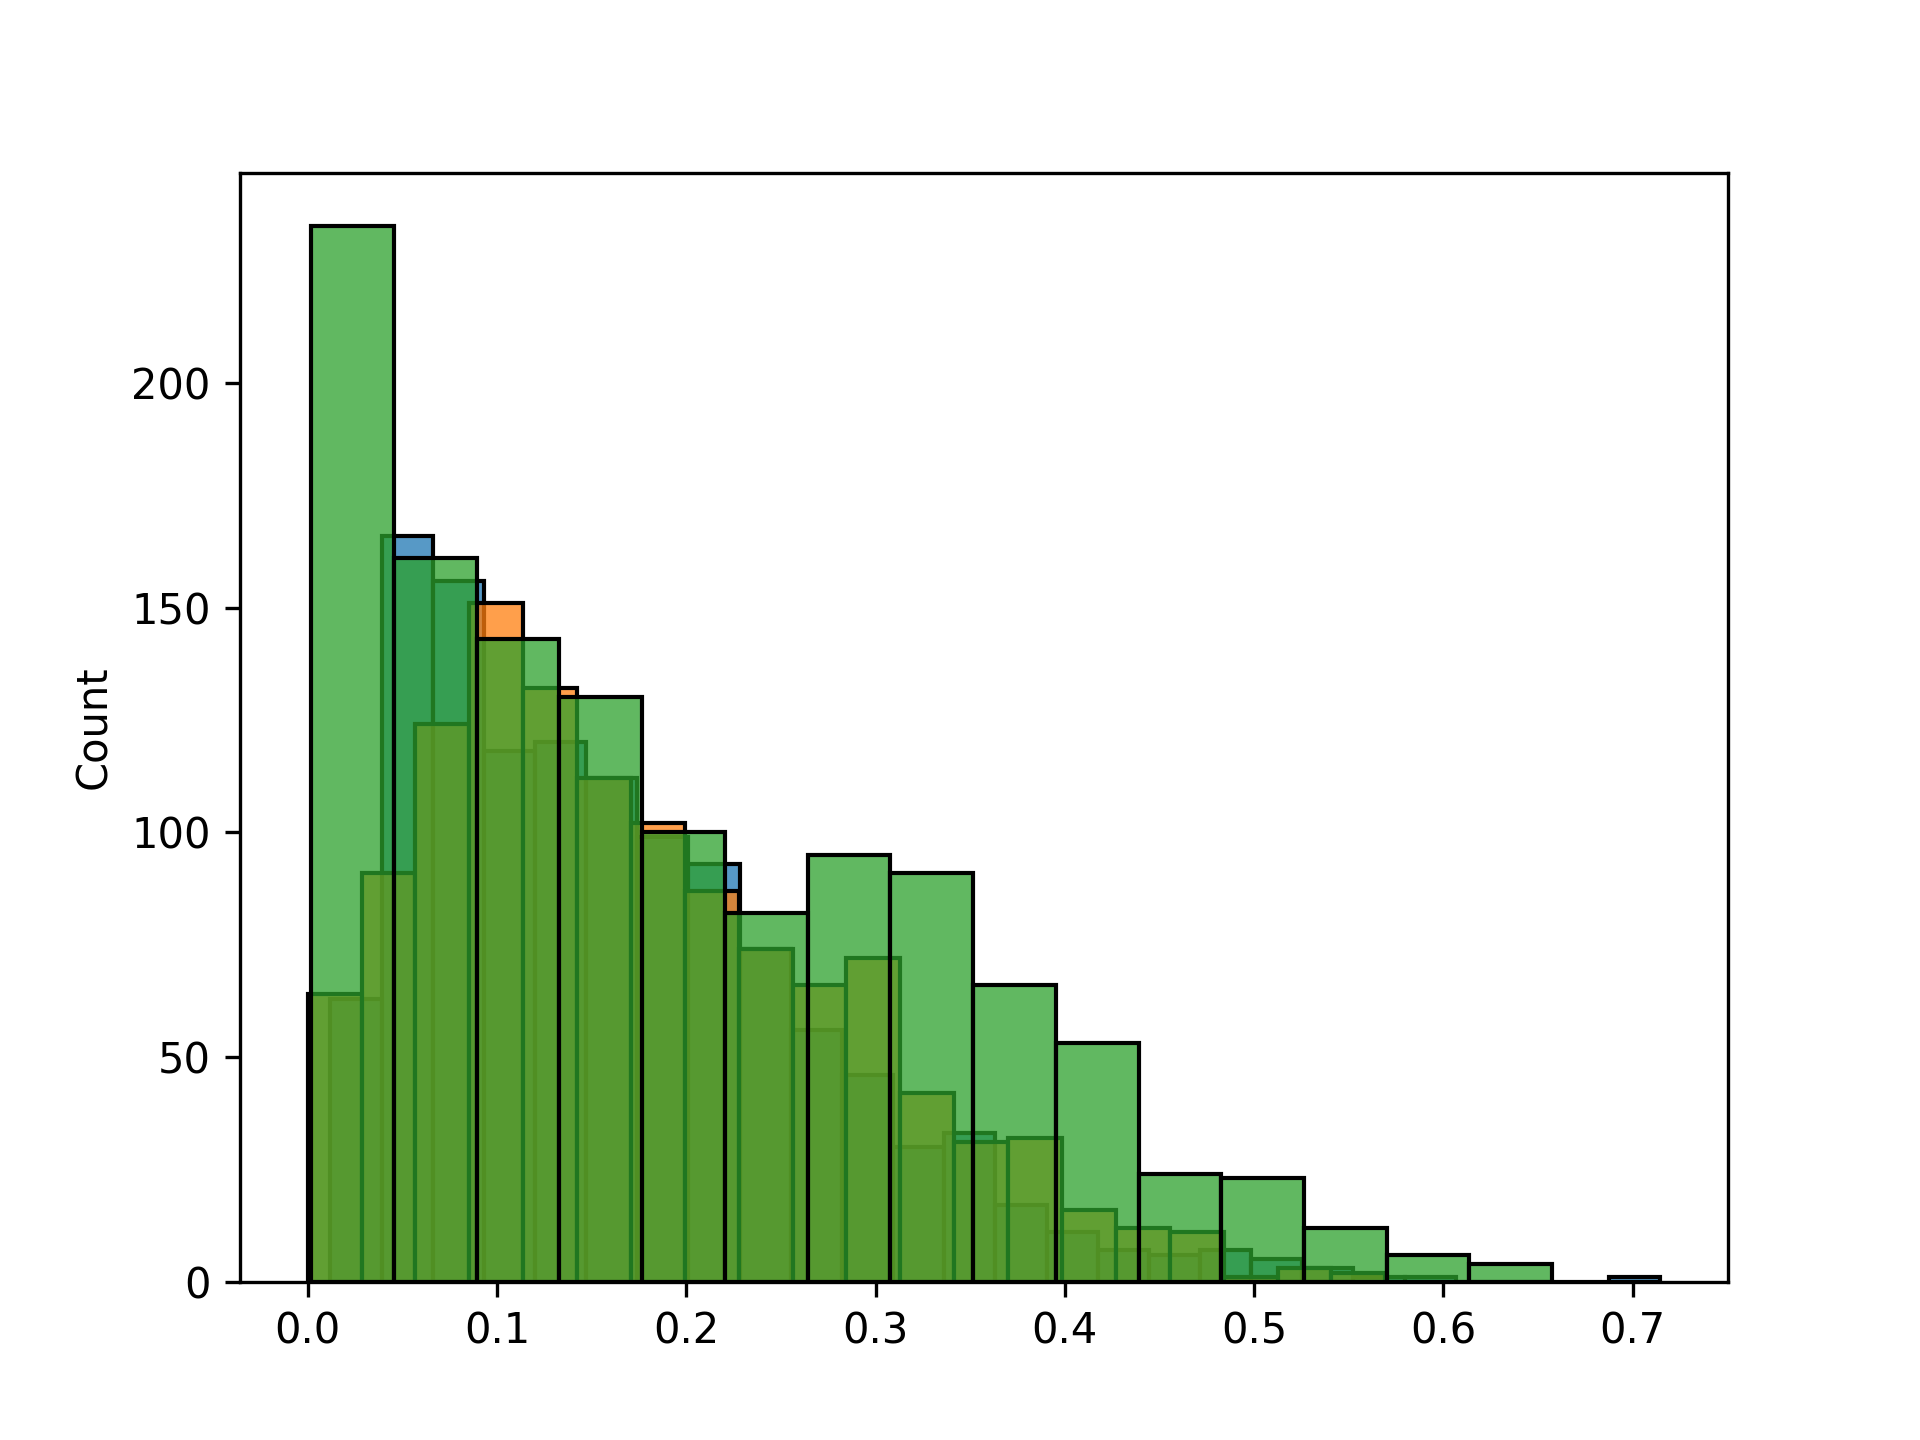

<Axes: ylabel='Count'>

In [197]:
sns.histplot(y_pred_mase)
sns.histplot(y_pred)
sns.histplot(probas_true[-1][subdiag])

In [33]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-6])
y_pred = np.clip(X_omni[-1] @ X_omni[-1].T, 0, 1)[subdiag]
y_true = Y[-1].toarray()[subdiag]

print(roc_auc_score(y_true, y_pred))
print(log_loss(y_true, y_pred))
print(np.mean((probas_true[-1][subdiag] - y_pred) ** 2))

0.7448362305480737
0.5259478514423953
0.004914252571990679


In [42]:
a(0.005 - 0.001) / 0.005

0.8

In [27]:
R, _ = orthogonal_procrustes(X_omni[-1], X[-1])

np.mean((X[-1] - X_omni[-1] @ R) ** 2)

0.008289357461321192

In [33]:
X_pred = rdpg.forecast_positions(k_steps=6, n_samples=1000).mean(axis=0)[-1]
R, _ = orthogonal_procrustes(X_pred, X[-1])

np.mean((X[-1] - X_pred @ R) ** 2)

0.002588750927915917